In [1]:
import numpy as np
import pandas as pd
import google.colab.patches as pathes
np.random.seed(10)

In [2]:
excel_path = "/content/drive/MyDrive/Colab Notebooks/泰坦尼克號生存模型/titanic3.xls"

In [3]:
all_df = pd.read_excel(excel_path)
all_df[:3]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [4]:
cols=['survived','name','pclass','sex','age','sibsp','parch','fare','embarked']
all_df=all_df[cols]
all_df[:3]

,survived,name,pclass,sex,age,sibsp,parch,fare,embarked
0,1,"Allen, Miss. Elisabeth Walton",1,female,29.0000,0,0,211.3375,S
1,1,"Allison, Master. Hudson Trevor",1,male,0.9167,1,2,151.5500,S
2,0,"Allison, Miss. Helen Loraine",1,female,2.0000,1,2,151.5500,S


In [5]:
df = all_df.drop(['name'], axis=1) # 刪除名字
df[:3]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,0,1,female,2.0000,1,2,151.5500,S


In [6]:
all_df.isnull().sum()

,0
survived,0
name,0
pclass,0
sex,0
age,263
sibsp,0
parch,0
fare,1
embarked,2


In [7]:
age_mean = df['age'].mean()
df['age'] = df['age'].fillna(age_mean)
fare_mean = df['fare'].mean()
df['fare'] = df['fare'].fillna(fare_mean)

In [8]:
df['sex'] = df['sex'].map({'female':0, 'male':1}).astype(int)
df[:3]

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,1,1,0,29.0000,0,0,211.3375,S
1,1,1,1,0.9167,1,2,151.5500,S
2,0,1,0,2.0000,1,2,151.5500,S


In [9]:
x_OneHot_df=pd.get_dummies(data=df,columns=['embarked'],dtype=int)
x_OneHot_df[:2]

,survived,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,1,1,0,29.0000,0,0,211.3375,0,0,1
1,1,1,1,0.9167,1,2,151.5500,0,0,1


In [10]:
ndarray= x_OneHot_df.values
ndarray.shape

(1309, 10)

In [11]:
ndarray[:3]

array([[  1.    ,   1.    ,   0.    ,  29.    ,   0.    ,   0.    ,
        211.3375,   0.    ,   0.    ,   1.    ],
       [  1.    ,   1.    ,   1.    ,   0.9167,   1.    ,   2.    ,
        151.55  ,   0.    ,   0.    ,   1.    ],
       [  0.    ,   1.    ,   0.    ,   2.    ,   1.    ,   2.    ,
        151.55  ,   0.    ,   0.    ,   1.    ]])

In [12]:
Label = ndarray[:,0]
Features = ndarray[:,1:]
Label[:2]

array([1., 1.])

In [13]:
Features[:2]

array([[  1.    ,   0.    ,  29.    ,   0.    ,   0.    , 211.3375,
          0.    ,   0.    ,   1.    ],
       [  1.    ,   1.    ,   0.9167,   1.    ,   2.    , 151.55  ,
          0.    ,   0.    ,   1.    ]])

In [14]:
from sklearn import preprocessing

In [15]:
minmax_scale = preprocessing.MinMaxScaler(feature_range=(0,1))

In [16]:
scaledFeatures = minmax_scale.fit_transform(Features)
scaledFeatures[:2]

array([[0.        , 0.        , 0.36116884, 0.        , 0.        ,
        0.41250333, 0.        , 0.        , 1.        ],
       [0.        , 1.        , 0.00939458, 0.125     , 0.22222222,
        0.2958059 , 0.        , 0.        , 1.        ]])

In [17]:
msk= np.random.rand(len(all_df))<0.8
train_df= all_df[msk]
test_df=all_df[~msk]

In [18]:
print('total:',len(all_df),', train: ',len(train_df),', test:',len(test_df))

total: 1309 , train:  1034 , test: 275


In [19]:
def PreprocessData(raw_df):
  df = raw_df.drop('name', axis=1)
  age_mean = df['age'].mean()
  df['age']=df['age'].fillna(age_mean)
  fare_mean= df['fare'].mean()
  df['fare']= df['fare'].fillna(fare_mean)
  df['sex']= df['sex'].map({'female':0,'male':1}).astype(int)
  x_OneHot_df= pd.get_dummies(data=df,columns=["embarked"],dtype=int)
  ndarray= x_OneHot_df.values
  Features=ndarray[:,1:]
  Label=ndarray[:,0]
  minmax_scale= preprocessing.MinMaxScaler(feature_range=(0,1))
  scaledFeature=minmax_scale.fit_transform(Features)
  return scaledFeature, Label

In [20]:
train_Features,train_Label= PreprocessData(train_df)
test_Features, test_Label= PreprocessData(test_df)

In [21]:
train_Features[:2]
train_Label[:2]

array([1., 1.])

In [22]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

In [23]:
model = Sequential()
model.add(Dense(units=40,input_dim=9,kernel_initializer='uniform',activation='relu'))
model.add(Dense(units=30,kernel_initializer='uniform',activation='relu'))
model.add(Dense(units=1,kernel_initializer='uniform',activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         1,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,661 (6.49 KB)

 Trainable params: 1,661 (6.49 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print(len(train_Features),len(train_Label))

1034 1034


In [25]:
train_history=model.fit(x=train_Features,y=train_Label,validation_split=0.1,epochs=30,batch_size=30,verbose=2)



Epoch 1/30
31/31 - 2s - 78ms/step - accuracy: 0.5871 - loss: 0.6887 - val_accuracy: 0.7885 - val_loss: 0.6654
Epoch 2/30
31/31 - 1s - 36ms/step - accuracy: 0.5968 - loss: 0.6616 - val_accuracy: 0.7885 - val_loss: 0.5742
Epoch 3/30
31/31 - 0s - 5ms/step - accuracy: 0.6613 - loss: 0.6091 - val_accuracy: 0.8077 - val_loss: 0.4979
Epoch 4/30
31/31 - 0s - 5ms/step - accuracy: 0.7409 - loss: 0.5584 - val_accuracy: 0.7692 - val_loss: 0.4655
Epoch 5/30
31/31 - 0s - 6ms/step - accuracy: 0.7677 - loss: 0.5205 - val_accuracy: 0.7500 - val_loss: 0.4504
Epoch 6/30
31/31 - 0s - 6ms/step - accuracy: 0.7624 - loss: 0.5018 - val_accuracy: 0.7885 - val_loss: 0.4558
Epoch 7/30
31/31 - 0s - 5ms/step - accuracy: 0.7581 - loss: 0.4925 - val_accuracy: 0.7885 - val_loss: 0.4523
Epoch 8/30
31/31 - 0s - 5ms/step - accuracy: 0.7634 - loss: 0.4869 - val_accuracy: 0.7788 - val_loss: 0.4390
Epoch 9/30
31/31 - 0s - 6ms/step - accuracy: 0.7591 - loss: 0.4801 - val_accuracy: 0.7981 - val_loss: 0.4418
Epoch 10/30
31/31

In [27]:
print("你的歷史紀錄裡面有的東西：", train_history.history.keys())

你的歷史紀錄裡面有的東西： dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


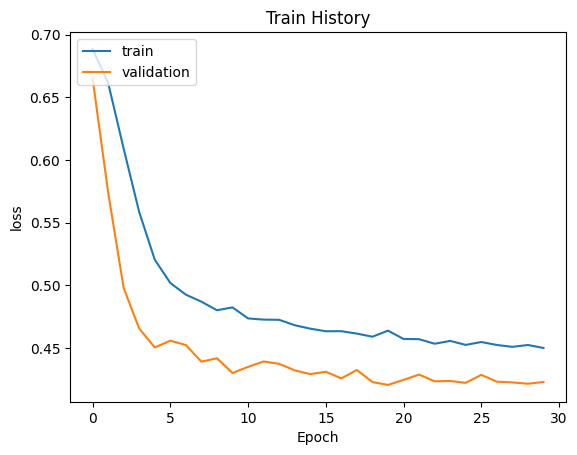

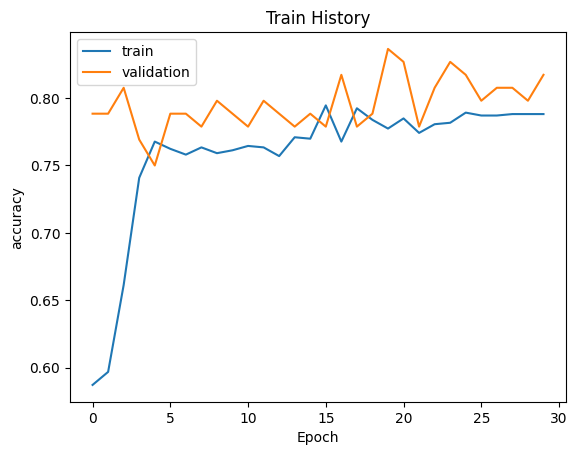

In [30]:
import matplotlib.pyplot as plt
def show_train_history(train_history,train,validation):
  plt.plot(train_history.history[train])
  plt.plot(train_history.history[validation])
  plt.title('Train History')
  plt.ylabel(train)
  plt.xlabel('Epoch')
  plt.legend(['train','validation'],loc='upper left')
  plt.show()
show_train_history(train_history, 'loss', 'val_loss')
show_train_history(train_history, 'accuracy', 'val_accuracy')

In [32]:
scores=model.evaluate(x=test_Features,y=test_Label)
scores[1]

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7964 - loss: 0.4409 


0.7963636517524719

In [34]:
Jack= pd.Series([0,'Jack',3,'male',23,1,0,5.0000,'S'])
Rose= pd.Series([1,'Rose',1,'female',20,1,0,100.0000,'S'])

In [36]:
JR_df=pd.DataFrame([list(Jack),list(Rose)],columns=['survived','name','pclass','sex','age','sibsp','parch','fare','embarked'])
all_df=pd.concat([all_df,JR_df])
all_df[-2:]

,survived,name,pclass,sex,age,sibsp,parch,fare,embarked
0,0,Jack,3,male,23.0,1,0,5.0,S
1,1,Rose,1,female,20.0,1,0,100.0,S


In [39]:
all_Features,Label = PreprocessData(all_df)
all_probability = model.predict(all_Features)
all_probability[:10]

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.97022295],
       [0.590371  ],
       [0.97230995],
       [0.3801519 ],
       [0.9685685 ],
       [0.26665467],
       [0.93764716],
       [0.31667608],
       [0.9390232 ],
       [0.30164924]], dtype=float32)

In [46]:
pd = all_df
pd.insert(len(all_df.columns),'probability',all_probability)
pd[-2:]


ValueError: cannot insert probability, already exists

In [47]:
pd[(pd['survived']==0)&(pd['probability']>0.9)]
pd[:5]

,survived,name,pclass,sex,age,sibsp,parch,fare,embarked,probability
0,1,"Allen, Miss. Elisabeth Walton",1,female,29.0000,0,0,211.3375,S,0.970223
1,1,"Allison, Master. Hudson Trevor",1,male,0.9167,1,2,151.5500,S,0.590371
2,0,"Allison, Miss. Helen Loraine",1,female,2.0000,1,2,151.5500,S,0.972310
3,0,"Allison, Mr. Hudson Joshua Creighton",1,male,30.0000,1,2,151.5500,S,0.380152
4,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,female,25.0000,1,2,151.5500,S,0.968569
